In [13]:
from abc import ABC, abstractmethod

import numpy as np
import random
import matplotlib.pyplot as plt
from copy import deepcopy

from PIL import Image, ImageDraw

In [3]:
TARGET_PATH = 'data\girl_pearl_earing.png'

target_img = Image.open(TARGET_PATH).convert("RGB")
target_array = np.array(target_img, dtype=np.float64)

print(f"Image Size: {target_img.size}")
print(f"Array shape: {target_array.shape}")

Image Size: (300, 400)
Array shape: (400, 300, 3)


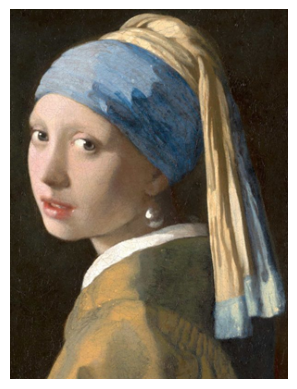

In [5]:
plt.imshow(target_img)
plt.axis("off")
plt.show()

In [6]:
IMG_WIDTH = 300
IMG_HEIGHT = 400

In [7]:
def random_triangle():
    vertices = [
        (random.randint(0, IMG_WIDTH), random.randint(0, IMG_HEIGHT)),
        (random.randint(0, IMG_WIDTH), random.randint(0, IMG_HEIGHT)),
        (random.randint(0, IMG_WIDTH), random.randint(0, IMG_HEIGHT))
    ]

    color = [
        random.randint(0,255), #R
        random.randint(0,255), #G
        random.randint(0,255), #B
        random.randint(30,180) #Alpha
    ]

    return {"vertices": vertices, "color": color}

In [15]:
class Solution(ABC):
    
    def __init__(self, repr=None):
        if repr is None:
            repr = self.random_initial_representation()
        self.repr = repr

    def __repr__(self):
        return str(self.repr)
    
    @abstractmethod
    def fitness(self) -> float:
        pass

    @abstractmethod
    def random_initial_representation(self):
        pass

In [16]:
class TriangleImageSolution(Solution):
    def __init__(self, target: np.ndarray, n_triangles: 100, repr=None):
        self.target = target
        self.n_triangles = n_triangles
        super().__init__(repr=repr)

    def random_initial_repr(self):
        for _ in range(self.n_triangles):
            return random_triangle()
        
    def fitness(self):
        pass